In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

Variants v.s. Hospitalization

In [5]:
variant = pd.read_csv("/Users/boyapeng/Desktop/Dissertation/Aim2/Data/SARS-CoV-2_Variant_Proportions_20260126.csv",header=0)
# ensure datetime
variant['Date'] = pd.to_datetime(variant['week_ending'].str.split().str[0], errors='raise')
variant["Date"] = pd.to_datetime(variant["Date"])

/var/folders/vy/m4l1bmcs7xd4nmd991yq7qkr0000gn/T/ipykernel_4674/83732617.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  variant = pd.read_csv("/Users/boyapeng/Desktop/Dissertation/Aim2/Data/SARS-CoV-2_Variant_Proportions_20260126.csv",header=0)


In [22]:
min_dates = variant["Date"].dropna().sort_values().unique()[:10]
print(min_dates)

<DatetimeArray>
['2021-01-02 00:00:00', '2021-01-16 00:00:00', '2021-01-30 00:00:00',
 '2021-02-06 00:00:00', '2021-02-13 00:00:00', '2021-02-20 00:00:00',
 '2021-02-27 00:00:00', '2021-03-06 00:00:00', '2021-03-13 00:00:00',
 '2021-03-20 00:00:00']
Length: 10, dtype: datetime64[ns]


In [98]:
variant[(variant['usa_or_hhsregion'] == '10') & (variant['variant'] == 'NB.1.8.1')] 
#(variant['Date'] == '2025-06-07') &  & (variant['variant'] == 'LP.8.1')& (variant["nchs_or_count_flag"] == 0.0) 

,usa_or_hhsregion,week_ending,variant,share,share_hi,share_lo,nchs_or_count_flag,modeltype,time_interval,published_date,Date
1254756,10,2025-04-12 00:00:00,NB.1.8.1,0.066667,0.235073,0.011632,1.0,empiric,4_week,2025-08-29 00:00:00,2025-04-12
1254765,10,2025-05-10 00:00:00,NB.1.8.1,0.069767,0.201226,0.018193,1.0,empiric,4_week,2025-08-29 00:00:00,2025-05-10
1254774,10,2025-06-07 00:00:00,NB.1.8.1,0.208333,0.427065,0.079360,1.0,empiric,4_week,2025-08-29 00:00:00,2025-06-07
1254777,10,2025-07-05 00:00:00,NB.1.8.1,0.166667,0.635177,0.008762,1.0,empiric,4_week,2025-08-29 00:00:00,2025-07-05
1254780,10,2025-08-02 00:00:00,NB.1.8.1,1.000000,1.000000,0.054621,1.0,empiric,4_week,2025-08-29 00:00:00,2025-08-02
...,...,...,...,...,...,...,...,...,...,...,...
3043180,10,2025-03-29 00:00:00,NB.1.8.1,0.000000,NaN,NaN,1.0,weighted,biweekly,2025-06-20 00:00:00,2025-03-29
3056660,10,2025-04-12 00:00:00,NB.1.8.1,0.066667,0.846875,0.000000,1.0,weighted,biweekly,2025-06-20 00:00:00,2025-04-12
3056764,10,2025-04-26 00:00:00,NB.1.8.1,0.000000,NaN,NaN,1.0,weighted,biweekly,2025-06-20 00:00:00,2025-04-26
3056868,10,2025-05-10 00:00:00,NB.1.8.1,0.047619,NaN,NaN,1.0,weighted,biweekly,2025-06-20 00:00:00,2025-05-10


In [82]:
#use time_interval='biweekly' from 1/30/2021, 'weekly' from 3/6/2021, biweekly from 4/15/2023, 4_week from 6/7/2025
def build_variant2(
    variant: pd.DataFrame,
    usa_or_hhsregion: str = "1",
    nchs_or_count_flag: float = 0.0,
    cut1: str = "2021-03-06",
    cut2: str = "2023-04-15",
    cut3: str = "2025-06-07",
    drop_col: str = "published_date",
    dedup_cols: list[str] = None,
) -> pd.DataFrame:
    """
    Filter and clean CDC variant data into variant2 with changing time_interval rules by date.

    Rules:
      - Date <  2021-03-06: biweekly
      - 2021-03-06 <= Date < 2023-04-15: weekly
      - 2023-04-15 <= Date < 2025-06-07: biweekly
      - Date >= 2025-06-07: 4_week

    Cleaning:
      - drop `published_date`
      - drop duplicates on dedup_cols
      - average duplicates within (usa_or_hhsregion, variant, Date)
        for share, share_hi, share_lo
    """

    if dedup_cols is None:
        dedup_cols = ["week_ending", "variant", "share"]

    df = variant.copy()

    # ensure datetime
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    t1 = pd.Timestamp(cut1)
    t2 = pd.Timestamp(cut2)
    t3 = pd.Timestamp(cut3)

    mask_geo = df["usa_or_hhsregion"].astype(str).eq(str(usa_or_hhsregion))
    mask_flag = df["nchs_or_count_flag"].eq(nchs_or_count_flag)

    mask_interval = (
        ((df["Date"] <  t1) & df["time_interval"].eq("biweekly")) |
        ((df["Date"] >= t1) & (df["Date"] <  t2) & df["time_interval"].eq("weekly")) |
        ((df["Date"] >= t2) & (df["Date"] <  t3) & df["time_interval"].eq("biweekly")) |
        ((df["Date"] >= t3) & df["time_interval"].eq("4_week"))
    )

    out = df.loc[mask_geo & mask_flag & mask_interval].copy()

    out = out.drop(columns=[drop_col], errors="ignore")
    out = out.drop_duplicates(subset=dedup_cols).copy()
    out = out.dropna(subset=["Date"])

    # --- aggregate duplicates ---
    agg_dict = {
        "share": "mean",
        "share_hi": "mean",
        "share_lo": "mean",
        "time_interval": "last",
        "modeltype": "last",
        "nchs_or_count_flag": "last",
    }

    out = (
        out
        .sort_values("Date")
        .groupby(["usa_or_hhsregion", "variant", "Date"], as_index=False)
        .agg(agg_dict)
        .sort_values("Date")
        .reset_index(drop=True)
    )

    return out

def build_all_regions(variant: pd.DataFrame):
    """
    Build variant datasets for usa_or_hhsregion = "1" to "10".
    Returns a dictionary of DataFrames.
    """
    region_dict = {}

    for i in range(1, 11):
        region_id = str(i)
        region_key = f"region_{i:02d}"   # <-- zero padded
        region_dict[region_key] = build_variant2(
            variant,
            usa_or_hhsregion=region_id
        )

    return region_dict


In [83]:
variant_hhs = build_all_regions(variant)

In [84]:
variant_hhs["region_01"]

,usa_or_hhsregion,variant,Date,share,share_hi,share_lo,time_interval,modeltype,nchs_or_count_flag
0,1,Other,2021-01-30,0.624071,0.719581,0.524529,biweekly,weighted,0.0
1,1,B.1,2021-01-30,0.078952,0.127429,0.048436,biweekly,weighted,0.0
2,1,B.1.596,2021-01-30,0.063955,0.103770,0.038755,biweekly,weighted,0.0
3,1,B.1.429,2021-01-30,0.038165,0.102067,0.013799,biweekly,weighted,0.0
4,1,B.1.526,2021-01-30,0.017224,0.028230,0.010463,biweekly,weighted,0.0
...,...,...,...,...,...,...,...,...,...
681,1,XFG,2025-08-02,0.742515,0.805537,0.668102,4_week,empiric,0.0
682,1,XFG,2025-08-30,0.774493,0.826829,0.712328,4_week,empiric,0.0
683,1,NB.1.8.1,2025-10-25,0.161616,0.252213,0.098000,4_week,empiric,0.0
684,1,XFG,2025-10-25,0.626263,0.719780,0.522823,4_week,empiric,0.0


In [86]:
# save as CSV
def combine_from_region_dict(region_dict, outpath="variant_hhs.csv"):
    combined = []

    for region_name, df in region_dict.items():
        temp = df.copy()
        temp["region"] = region_name
        combined.append(temp)

    combined_df = pd.concat(combined, ignore_index=True)
    combined_df = combined_df.sort_values(["region", "Date"])

    combined_df.to_csv(outpath, index=False)

    return combined_df


# Run directly on existing output
variant_all = combine_from_region_dict(variant_hhs)

In [89]:
#impute
pd.set_option("future.no_silent_downcasting", True)
def impute_weekly_variant_share(
    df: pd.DataFrame,
    group_cols=("usa_or_hhsregion", "variant"),
    date_col="Date",
    share_cols=("share", "share_hi", "share_lo"),
    freq="7D",
) -> pd.DataFrame:
    """
    Group by (usa_or_hhsregion, variant), sort by Date, and impute missing weekly dates.

    Rules:
      - Build a weekly grid within each group (min(Date) -> max(Date), step = 7 days).
      - For missing weekly dates:
          * share/share_hi/share_lo are imputed by linear interpolation
            (for a single missing week between 2 endpoints, this equals the mean).
          * nchs_or_count_flag is set to NA for imputed rows.
          * usa_or_hhsregion, time_interval, region, modeltype are forward-filled
            (i.e., repeated from the last available record).
    """
    out = df.copy()

    # Ensure datetime
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col])

    # Sort once for stability
    sort_cols = list(group_cols) + [date_col]
    out = out.sort_values(sort_cols).reset_index(drop=True)

    # Columns to forward-fill from the last record
    ffill_cols = []
    for c in ["usa_or_hhsregion", "time_interval", "region", "modeltype"]:
        if c in out.columns and c not in share_cols and c != date_col:
            ffill_cols.append(c)

    # Keep original presence mask per group for "imputed row" detection
    results = []
    for keys, g in out.groupby(list(group_cols), sort=False):
        g = g.sort_values(date_col).copy()

        # Weekly grid
        full_dates = pd.date_range(g[date_col].min(), g[date_col].max(), freq=freq)
        g = g.set_index(date_col)

        # Reindex to full weekly grid
        g_full = g.reindex(full_dates)

        # Mark which rows are newly created (imputed dates)
        is_imputed = g_full.index.difference(g.index)
        g_full["_is_imputed"] = g_full.index.isin(is_imputed)

        # Forward-fill constant-ish columns from last record
        for c in ffill_cols:
            g_full[c] = g_full[c].ffill()

        # Interpolate share columns (linear -> for single missing week = mean of endpoints)
        for c in share_cols:
            if c in g_full.columns:
                g_full[c] = g_full[c].interpolate(method="linear", limit_area="inside")

        # Set nchs_or_count_flag to NA for imputed rows only (keep original for observed rows)
        if "nchs_or_count_flag" in g_full.columns:
            g_full.loc[g_full["_is_imputed"], "nchs_or_count_flag"] = np.nan

        # Restore group keys if they got lost (safety)
        if isinstance(keys, tuple):
            for col, val in zip(group_cols, keys):
                g_full[col] = g_full[col].fillna(val)
        else:
            g_full[group_cols[0]] = g_full[group_cols[0]].fillna(keys)

        # Back to column Date
        g_full = g_full.reset_index().rename(columns={"index": date_col})

        results.append(g_full)

    out2 = pd.concat(results, ignore_index=True)

    # Optional: drop helper
    out2 = out2.drop(columns=["_is_imputed"], errors="ignore")

    # Final sort
    out2 = out2.sort_values(list(group_cols) + [date_col]).reset_index(drop=True)
    return out2


# Example usage:
variant_all_imputed = impute_weekly_variant_share(variant_all)

In [90]:
variant_all_imputed.to_csv('variant_hhs_imputed.csv', index=False)

In [91]:
def build_marker_wide(
    variant2_all: pd.DataFrame,
    region_col: str = "region",
    geo_col: str = "usa_or_hhsregion",
    date_col: str = "Date",
    variant_col: str = "variant",
    share_col: str = "share",
    exclude_variant: str = "Other",
    outpath: str = "variant_hhs_marker.csv",
) -> pd.DataFrame:
    """
    Same output format as before, but works on COMBINED (all regions) data.

    For EACH region separately:
      - wide shares: one row per Date, columns = variants (mean if duplicates)
      - dominant variant each date within region
      - marker rule:
          * start_date = first non-NA share for that variant within region
          * if variant is ever dominant within region -> marker 1 at start_date else 2
          * after start_date: 0 when present (share notna), NaN when absent

    Returns a LONG table stacking all regions' wide tables, with columns:
      usa_or_hhsregion, region, Date, <variant>_share, <variant>_marker, ...
    """
    df = variant2_all.copy()

    # 1) exclude Other
    df = df.loc[df[variant_col].ne(exclude_variant)].copy()

    # 2) ensure datetime Date
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.loc[df[date_col].notna()].copy()

    # keep only needed columns (plus meta keys)
    keep_cols = [geo_col, region_col, date_col, variant_col, share_col]
    df = df[[c for c in keep_cols if c in df.columns]].copy()

    # ensure geo is string like before
    df[geo_col] = df[geo_col].astype(str)

    wide_list = []

    # iterate regions present in the combined data
    for (geo_val, region_val), g in df.groupby([geo_col, region_col], sort=True):
        # wide shares (one row per Date) for this region
        shares = (
            g.pivot_table(index=date_col, columns=variant_col, values=share_col, aggfunc="mean")
             .sort_index()
        )

        # dominant variant each date (within this region)
        dominant = shares.idxmax(axis=1)
        ever_dominant = set(dominant.dropna().unique())

        # marker matrix
        markers = pd.DataFrame(np.nan, index=shares.index, columns=shares.columns)

        for v in shares.columns:
            s = shares[v]
            start_date = s.first_valid_index()
            if start_date is None:
                continue

            markers.loc[start_date, v] = 1 if v in ever_dominant else 2
            mask_after = (shares.index > start_date) & s.notna()
            markers.loc[mask_after, v] = 0

        # rename + combine (same as original)
        shares = shares.add_suffix("_share")
        markers = markers.add_suffix("_marker")
        out = pd.concat([shares, markers], axis=1)

        # consistent ordering (variant_share then variant_marker)
        variants = shares.columns.str.replace("_share$", "", regex=True)
        ordered_cols = []
        for v in sorted(variants):
            ordered_cols.append(f"{v}_share")
            ordered_cols.append(f"{v}_marker")
        out = out.reindex(columns=ordered_cols).reset_index()

        # add region identifiers (same placement as before)
        out.insert(0, geo_col, geo_val)
        out.insert(1, region_col, region_val)

        wide_list.append(out)

    wide_all = pd.concat(wide_list, ignore_index=True)
    wide_all.to_csv(outpath, index=False)
    return wide_all
    

In [93]:
wide_all_regions = build_marker_wide(variant_all_imputed, outpath="variant_hhs_marker.csv")

In [100]:
def save_by_hhs_region(wide_all: pd.DataFrame, out_dir="/Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs"):
    
    wide_all["usa_or_hhsregion"] = wide_all["usa_or_hhsregion"].astype(int)

    for r in range(1, 11):
        df_r = wide_all.loc[wide_all["usa_or_hhsregion"] == r].copy()

        outpath = f"{out_dir}/variant_hhs_marker_region_{r:02d}.csv"
        df_r.to_csv(outpath, index=False)

        print(f"Saved: {outpath}")


# usage
save_by_hhs_region(wide_all_regions)

Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_01.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_02.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_03.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_04.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_05.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_06.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_07.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_08.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_09.csv
Saved: /Users/boyapeng/Desktop/Dissertation/Aim2/Data/variants_hhs/variant_hhs_marker_region_10.csv


In [ ]:
# variants distribution

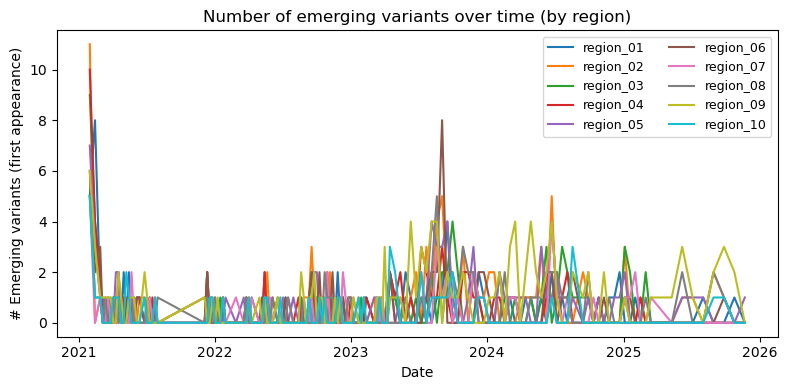

In [55]:
def plot_emerging_variants_over_time(
    variant_all: pd.DataFrame,
    date_col: str = "Date",
    variant_col: str = "variant",
    share_col: str = "share",
    region_col: str = "region",
    exclude_other: bool = True,
    title: str = "Number of emerging variants over time (by region)",
):
    """
    "Emerging variant" = the first date a variant appears (first non-NA share) within a region.
    Plots, for each region, the COUNT of newly emerging variants at each date (10 regions in one plot).
    """

    df = variant_all.copy()

    # basic cleanup
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.loc[df[date_col].notna()].copy()

    if exclude_other:
        df = df.loc[df[variant_col].ne("Other")].copy()

    # ensure share is numeric (in case strings)
    df[share_col] = pd.to_numeric(df[share_col], errors="coerce")

    # first appearance date per (region, variant): min Date where share is not NA
    first_dates = (
        df.loc[df[share_col].notna(), [region_col, variant_col, date_col]]
          .groupby([region_col, variant_col], as_index=False)[date_col]
          .min()
          .rename(columns={date_col: "emerge_date"})
    )

    # count emerging variants per (region, date)
    emerge_counts = (
        first_dates.groupby([region_col, "emerge_date"])
                   .size()
                   .reset_index(name="n_emerging")
    )

    # wide: index = date, columns = region
    wide = (
        emerge_counts.pivot_table(
            index="emerge_date", columns=region_col, values="n_emerging", aggfunc="sum"
        )
        .fillna(0)
        .sort_index()
    )

    # plot (one plot, 10 lines)
    plt.figure(figsize=(8, 4))
    for reg in wide.columns:
        plt.plot(wide.index, wide[reg], label=reg)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("# Emerging variants (first appearance)")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return wide


# ===== usage =====
# variant_all = combine_from_region_dict(variant_hhs)
emerging_wide = plot_emerging_variants_over_time(variant_all)

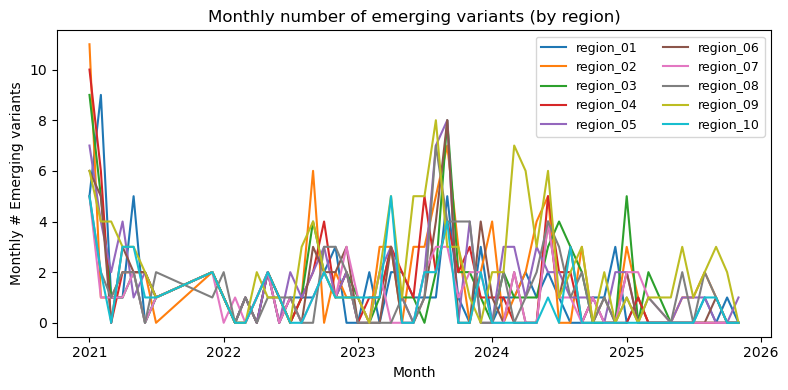

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_monthly_emerging_variants(
    variant_all: pd.DataFrame,
    date_col: str = "Date",
    variant_col: str = "variant",
    share_col: str = "share",
    region_col: str = "region",
    exclude_other: bool = True,
    title: str = "Monthly number of emerging variants (by region)",
    width: float = 12,
    height: float = 6,
):
    """
    Plot monthly SUM of newly emerging variants for 10 regions.
    width and height control figure size.
    """

    df = variant_all.copy()

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.loc[df[date_col].notna()].copy()

    if exclude_other:
        df = df.loc[df[variant_col].ne("Other")].copy()

    df[share_col] = pd.to_numeric(df[share_col], errors="coerce")

    # First appearance per (region, variant)
    first_dates = (
        df.loc[df[share_col].notna(), [region_col, variant_col, date_col]]
          .groupby([region_col, variant_col], as_index=False)[date_col]
          .min()
          .rename(columns={date_col: "emerge_date"})
    )

    first_dates["month"] = (
        first_dates["emerge_date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    monthly_counts = (
        first_dates.groupby([region_col, "month"])
                   .size()
                   .reset_index(name="n_emerging")
    )

    wide = (
        monthly_counts.pivot_table(
            index="month",
            columns=region_col,
            values="n_emerging",
            aggfunc="sum"
        )
        .fillna(0)
        .sort_index()
    )

    # Plot with custom size
    plt.figure(figsize=(width, height))

    for reg in wide.columns:
        plt.plot(wide.index, wide[reg], label=reg)

    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Monthly # Emerging variants")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    return wide


# Example usage:
monthly_emerging = plot_monthly_emerging_variants(
    variant_all_imputed,
    width=8,
    height=4
)

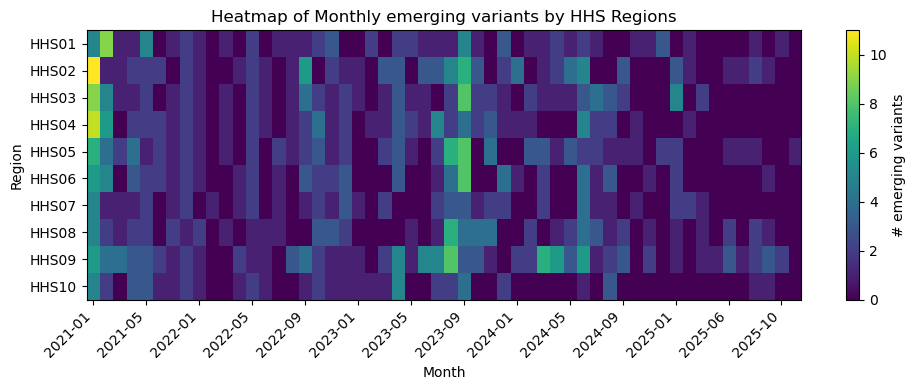

In [95]:
def plot_monthly_emerging_heatmap(
    monthly_wide: pd.DataFrame,
    title="Heatmap of Monthly emerging variants by HHS Regions",
    outpath="monthly_emerging_heatmap.jpg"
):
    """
    monthly_wide:
        index = month (datetime)
        columns = region_01 ... region_10
        values = monthly emerging counts
    """

    wide = monthly_wide.copy().sort_index()
    wide = wide.reindex(sorted(wide.columns), axis=1)

    # Convert region_XX → HHSXX
    new_labels = [f"HHS{col.split('_')[1]}" for col in wide.columns]

    fig, ax = plt.subplots(figsize=(10, 4))

    im = ax.imshow(wide.T.values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Region")

    # Y labels
    ax.set_yticks(range(len(new_labels)))
    ax.set_yticklabels(new_labels)

    # Reduce x ticks for readability
    step = max(1, wide.shape[0] // 12)
    x_idx = list(range(0, wide.shape[0], step))
    ax.set_xticks(x_idx)
    ax.set_xticklabels(
        [wide.index[i].strftime("%Y-%m") for i in x_idx],
        rotation=45,
        ha="right"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("# emerging variants")

    plt.tight_layout()

    plt.savefig(outpath, dpi=300, bbox_inches="tight", format="jpg")
    plt.show()
    
plot_monthly_emerging_heatmap(monthly_emerging,outpath="HHS_monthly_emerging_variants.jpg")